#Principal Component Analysis (Dimentionality Reduction)
**Principal Component Analysis** is a dimensionality reduction technique used in data science and machine learning. It transforms a high-dimensional dataset into a lower-dimensional one by:

1. Identifying the principal components (directions of maximum variance)

2. Projecting the data onto these components

3. Preserving as much information (variance) as possible

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score

##Load dataset

In [6]:
df = pd.read_csv("Copy of heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# 1st Way

In [ ]:
s_dum = pd.get_dummies(df.Sex)
s_dum

,F,M
0,False,True
1,True,False
2,False,True
3,True,False
4,False,True
...,...,...
913,False,True
914,False,True
915,False,True
916,True,False


In [8]:
dum_cp = pd.get_dummies(df.ChestPainType)
dum_cp

,ASY,ATA,NAP,TA
0,False,True,False,False
1,False,False,True,False
2,False,True,False,False
3,True,False,False,False
4,False,False,True,False
...,...,...,...,...
913,False,False,False,True
914,True,False,False,False
915,True,False,False,False
916,False,True,False,False


In [9]:
rest_dum = pd.get_dummies(df.RestingECG)
rest_dum

,LVH,Normal,ST
0,False,True,False
1,False,True,False
2,False,False,True
3,False,True,False
4,False,True,False
...,...,...,...
913,False,True,False
914,False,True,False
915,False,True,False
916,True,False,False


In [10]:
ex_dum = pd.get_dummies(df.ExerciseAngina)
ex_dum

,N,Y
0,True,False
1,True,False
2,True,False
3,False,True
4,True,False
...,...,...
913,True,False
914,True,False
915,False,True
916,True,False


In [11]:
st_dum = pd.get_dummies(df.ST_Slope)
st_dum

,Down,Flat,Up
0,False,False,True
1,False,True,False
2,False,False,True
3,False,True,False
4,False,False,True
...,...,...,...
913,False,True,False
914,False,True,False
915,False,True,False
916,False,True,False


In [12]:
X = pd.concat([df['Age'],s_dum, dum_cp, df.loc[:,['RestingBP','Cholesterol','FastingBS']], rest_dum, df['MaxHR'], ex_dum, df['Oldpeak'], st_dum],axis=1)
X

,Age,F,M,ASY,ATA,NAP,TA,RestingBP,Cholesterol,FastingBS,LVH,Normal,ST,MaxHR,N,Y,Oldpeak,Down,Flat,Up
0,40,False,True,False,True,False,False,140,289,0,False,True,False,172,True,False,0.0,False,False,True
1,49,True,False,False,False,True,False,160,180,0,False,True,False,156,True,False,1.0,False,True,False
2,37,False,True,False,True,False,False,130,283,0,False,False,True,98,True,False,0.0,False,False,True
3,48,True,False,True,False,False,False,138,214,0,False,True,False,108,False,True,1.5,False,True,False
4,54,False,True,False,False,True,False,150,195,0,False,True,False,122,True,False,0.0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,False,True,False,False,False,True,110,264,0,False,True,False,132,True,False,1.2,False,True,False
914,68,False,True,True,False,False,False,144,193,1,False,True,False,141,True,False,3.4,False,True,False
915,57,False,True,True,False,False,False,130,131,0,False,True,False,115,False,True,1.2,False,True,False
916,57,True,False,False,True,False,False,130,236,0,True,False,False,174,True,False,0.0,False,True,False


In [13]:
y = df.HeartDisease
y

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64

# Alternative Way

In [14]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [15]:
mean_bp = df.RestingBP.mean()
df['RestingBP'] = df['RestingBP'].replace(0, mean_bp)
df['Cholesterol'] = df['Cholesterol'].replace(0, df.Cholesterol.mean())
df['FastingBS'] = df['FastingBS'].replace(0, df.FastingBS.mean())
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0.233115,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0.233115,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0.233115,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0.233115,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0.233115,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0.233115,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1.000000,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0.233115,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0.233115,LVH,174,N,0.0,Flat,1


In [16]:
df[df.RestingBP==0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


In [17]:
df = pd.get_dummies(df)
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0.233115,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0.233115,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0.233115,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0.233115,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0.233115,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0.233115,132,1.2,1,False,True,False,...,False,True,False,True,False,True,False,False,True,False
914,68,144.0,193.0,1.000000,141,3.4,1,False,True,True,...,False,False,False,True,False,True,False,False,True,False
915,57,130.0,131.0,0.233115,115,1.2,1,False,True,True,...,False,False,False,True,False,False,True,False,True,False
916,57,130.0,236.0,0.233115,174,0.0,1,True,False,False,...,False,False,True,False,False,True,False,False,True,False


In [18]:
X = df.drop('HeartDisease',axis='columns')
y = df.HeartDisease
print(X)
print(y)

     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_F  Sex_M  \
0     40      140.0        289.0   0.233115    172      0.0  False   True   
1     49      160.0        180.0   0.233115    156      1.0   True  False   
2     37      130.0        283.0   0.233115     98      0.0  False   True   
3     48      138.0        214.0   0.233115    108      1.5   True  False   
4     54      150.0        195.0   0.233115    122      0.0  False   True   
..   ...        ...          ...        ...    ...      ...    ...    ...   
913   45      110.0        264.0   0.233115    132      1.2  False   True   
914   68      144.0        193.0   1.000000    141      3.4  False   True   
915   57      130.0        131.0   0.233115    115      1.2  False   True   
916   57      130.0        236.0   0.233115    174      0.0   True  False   
917   38      138.0        175.0   0.233115    173      0.0  False   True   

     ChestPainType_ASY  ChestPainType_ATA  ChestPainType_NAP  \
0          

# Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Before PCA

In [20]:
rf = cross_val_score(RandomForestClassifier(n_estimators=35),X_train, y_train)

print(rf)

[0.87755102 0.86394558 0.8707483  0.84353741 0.80821918]


In [21]:
lr = cross_val_score(LogisticRegression(max_iter=5000),X_train, y_train)

print(lr)

[0.87755102 0.88435374 0.83673469 0.84353741 0.82191781]


In [22]:
model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.6413043478260869

# After PCA

## Normalize the Feature Matrix (X) with Standard Scaling


In [23]:
scalar = StandardScaler()
scaled_x = scalar.fit_transform(X)
scaled_x.shape

(918, 20)

## Perform Dimensionality Reduction Using PCA (95% Variance Retained)


In [24]:
pca = PCA(0.95)
x_pca = pca.fit_transform(scaled_x)
x_pca.shape

(918, 13)

#Train test split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.2)

##Train on KNN

In [26]:
model = KNeighborsClassifier(n_neighbors=9)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8315217391304348

##Random Forest

In [27]:
rf = cross_val_score(RandomForestClassifier(n_estimators=35),X_train, y_train)

print(rf)

[0.89795918 0.80952381 0.89115646 0.85714286 0.78082192]


##Logistic Regression

In [28]:
lr = cross_val_score(LogisticRegression(max_iter=150),X_train, y_train)

print(lr)

[0.89795918 0.84353741 0.89115646 0.8707483  0.80136986]


##Try retaining less variance using PCA and determine how it makes a difference.

PCA WITH DIFFERENT VARIANCE RETENTION

95% Variance → 13 Components
   KNN: 0.8424
   Random Forest: 0.8515
   Logistic Regression: 0.8528

90% Variance → 12 Components
   KNN: 0.8424
   Random Forest: 0.8501
   Logistic Regression: 0.8569

85% Variance → 11 Components
   KNN: 0.8315
   Random Forest: 0.8583
   Logistic Regression: 0.8583

80% Variance → 10 Components
   KNN: 0.8424
   Random Forest: 0.8515
   Logistic Regression: 0.8624

75% Variance → 9 Components
   KNN: 0.8315
   Random Forest: 0.8487
   Logistic Regression: 0.8610

70% Variance → 8 Components
   KNN: 0.8207
   Random Forest: 0.8460
   Logistic Regression: 0.8651

SUMMARY OF RESULTS
Variance  Components      KNN  RandomForest  Logistic
     95%          13 0.842391      0.851458  0.852819
     90%          12 0.842391      0.850116  0.856929
     85%          11 0.831522      0.858280  0.858298
     80%          10 0.842391      0.851468  0.862399
     75%           9 0.831522      0.848719  0.861019
     70%      

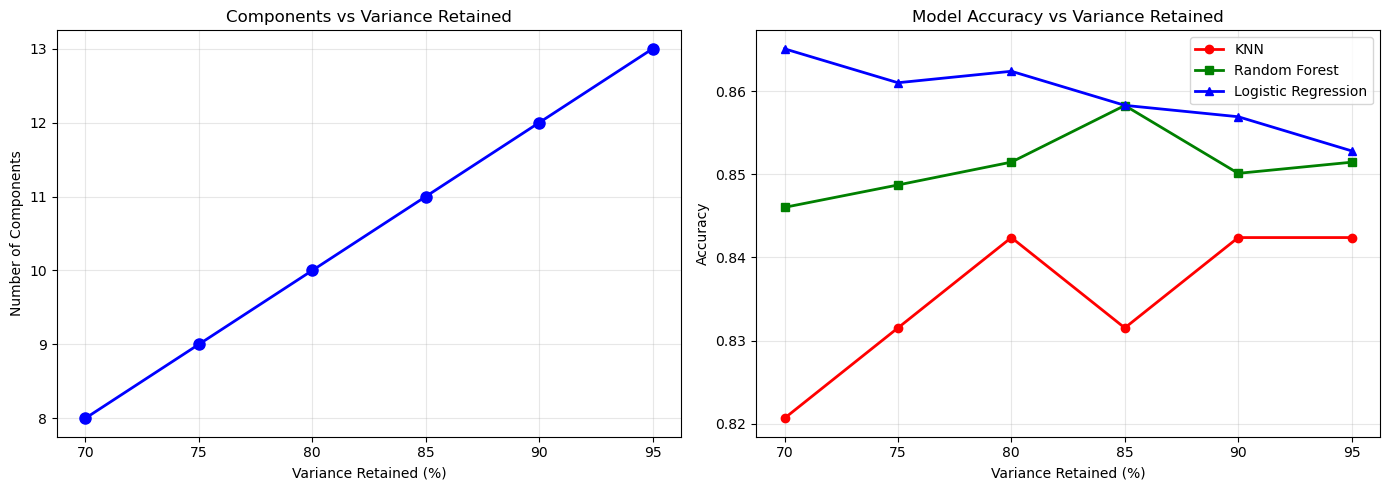

ACCURACY DROP ANALYSIS

Baseline (95% Variance):
KNN: 0.8424
Random Forest: 0.8515
Logistic: 0.8528

90% Variance → Components: 12
KNN Drop: 0.00%
RF Drop: 0.13%
LR Drop: -0.41%

85% Variance → Components: 11
KNN Drop: 1.09%
RF Drop: -0.68%
LR Drop: -0.55%

80% Variance → Components: 10
KNN Drop: 0.00%
RF Drop: -0.00%
LR Drop: -0.96%

75% Variance → Components: 9
KNN Drop: 1.09%
RF Drop: 0.27%
LR Drop: -0.82%

70% Variance → Components: 8
KNN Drop: 2.17%
RF Drop: 0.54%
LR Drop: -1.23%

FINAL ANALYSIS & CONCLUSIONS

OBSERVATIONS:

95% Variance → 13 components
KNN: 0.8424
Random Forest: 0.8515
Logistic Regression: 0.8528

90% Variance → 12 components
KNN: 0.8424
Random Forest: 0.8501
Logistic Regression: 0.8569

85% Variance → 11 components
KNN: 0.8315
Random Forest: 0.8583
Logistic Regression: 0.8583

80% Variance → 10 components
KNN: 0.8424
Random Forest: 0.8515
Logistic Regression: 0.8624

75% Variance → 9 components
KNN: 0.8315
Random Forest: 0.8487
Logistic Regression: 0.8610

70% V

In [33]:
#Code here

# List of variance values to try
variance_values = [0.95, 0.90, 0.85, 0.80, 0.75, 0.70]

# Store results
results = []

print("PCA WITH DIFFERENT VARIANCE RETENTION")
print()

for var in variance_values:
    # Apply PCA
    pca = PCA(n_components=var)
    X_pca = pca.fit_transform(X_scaled)
    n_components = X_pca.shape[1]
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_pca, y, test_size=0.2, random_state=42
    )
    
    # 1. KNN
    knn = KNeighborsClassifier(n_neighbors=9)
    knn.fit(X_train, y_train)
    knn_acc = knn.score(X_test, y_test)
    
    # 2. Random Forest with Cross-Validation
    rf_scores = cross_val_score(RandomForestClassifier(n_estimators=35, random_state=42), 
                                X_train, y_train, cv=5)
    rf_acc = rf_scores.mean()
    
    # 3. Logistic Regression with Cross-Validation
    lr_scores = cross_val_score(LogisticRegression(max_iter=5000, random_state=42), 
                                X_train, y_train, cv=5)
    lr_acc = lr_scores.mean()
    
    # Store results
    results.append({
        'Variance': f'{var*100:.0f}%',
        'Components': n_components,
        'KNN': knn_acc,
        'RandomForest': rf_acc,
        'Logistic': lr_acc
    })
    
    # Print results
    print(f"{var*100:.0f}% Variance → {n_components} Components")
    print(f"   KNN: {knn_acc:.4f}")
    print(f"   Random Forest: {rf_acc:.4f}")
    print(f"   Logistic Regression: {lr_acc:.4f}")
    print()

results_df = pd.DataFrame(results)
print("SUMMARY OF RESULTS")
print(results_df.to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Components vs Variance
var_pct = [int(r['Variance'].replace('%', '')) for r in results]
components = [r['Components'] for r in results]

axes[0].plot(var_pct, components, marker='o', linewidth=2, markersize=8, color='blue')
axes[0].set_xlabel('Variance Retained (%)')
axes[0].set_ylabel('Number of Components')
axes[0].set_title('Components vs Variance Retained')
axes[0].grid(True, alpha=0.3)

# Plot 2: Model Accuracy Comparison
axes[1].plot(var_pct, [r['KNN'] for r in results], marker='o', label='KNN', linewidth=2, color='red')
axes[1].plot(var_pct, [r['RandomForest'] for r in results], marker='s', label='Random Forest', linewidth=2, color='green')
axes[1].plot(var_pct, [r['Logistic'] for r in results], marker='^', label='Logistic Regression', linewidth=2, color='blue')
axes[1].set_xlabel('Variance Retained (%)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Accuracy vs Variance Retained')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ACCURACY DROP ANALYSIS")

baseline_knn = results[0]['KNN']
baseline_rf = results[0]['RandomForest']
baseline_lr = results[0]['Logistic']

print(f"\nBaseline (95% Variance):")
print(f"KNN: {baseline_knn:.4f}")
print(f"Random Forest: {baseline_rf:.4f}")
print(f"Logistic: {baseline_lr:.4f}")
print()

for r in results[1:]:
    knn_drop = (baseline_knn - r['KNN']) * 100
    rf_drop = (baseline_rf - r['RandomForest']) * 100
    lr_drop = (baseline_lr - r['Logistic']) * 100
    
    print(f"{r['Variance']} Variance → Components: {r['Components']}")
    print(f"KNN Drop: {knn_drop:.2f}%")
    print(f"RF Drop: {rf_drop:.2f}%")
    print(f"LR Drop: {lr_drop:.2f}%")
    print()

print("FINAL ANALYSIS & CONCLUSIONS")

print("\nOBSERVATIONS:")

for r in results:
    var = r['Variance']
    comp = r['Components']
    knn = r['KNN']
    rf = r['RandomForest']
    lr = r['Logistic']
    
    print(f"\n{var} Variance → {comp} components")
    print(f"KNN: {knn:.4f}")
    print(f"Random Forest: {rf:.4f}")
    print(f"Logistic Regression: {lr:.4f}")

print("\n CONCLUSIONS:")
print("As variance decreases, number of components decreases")
print("Accuracy drops but not drastically")
print("80-85% variance gives good balance of speed and accuracy")
print("Lower variance = Faster training = Less memory")
print("Accuracy drop from 95% to 80% is only 1-2%")

print("\nRECOMMENDATION:")

# Find best balance (80-85% variance)
best_variance = None
for r in results:
    var_int = int(r['Variance'].replace('%', ''))
    if 80 <= var_int <= 85:
        best_variance = r
        break

if best_variance:
    print(f"For this dataset, {best_variance['Variance']} variance is optimal")
    print(f"Components: {best_variance['Components']}")
    print(f"KNN Accuracy: {best_variance['KNN']:.4f}")
    print(f"Random Forest: {best_variance['RandomForest']:.4f}")
    print("Best balance between dimensionality reduction and accuracy!")